In [1]:
import pandas as pd
import numpy as np
import copy
us_dc_sales = pd.read_pickle('/Users/ppavuluri/Desktop/us_dc_sales.pkl')
us_cc_sales = pd.read_pickle('/Users/ppavuluri/Desktop/us_cc_sales.pkl')
us_dme_sales = pd.read_pickle('/Users/ppavuluri/Desktop/us_dme_sales.pkl')

In [2]:
us_cc_sales.head()

,date,geo,response1,response2
0,2022-10-19,810,1835.16,7
1,2022-10-21,611,1463.28,6
2,2022-10-22,623,52621.20,189
3,2022-10-24,686,4491.84,18
4,2022-10-26,637,3346.56,12


In [3]:
us_dc_sales.head()

,date,geo,response1,response2
0,2022-10-13,500,4197.840000,18
1,2022-10-13,501,124394.323085,510
2,2022-10-13,502,1115.400000,5
3,2022-10-13,503,1679.160000,7
4,2022-10-13,504,38020.440000,160


In [4]:
#getting rid of portland and Washington(DC) DMAs from the data
us_cc_sales = us_cc_sales[~us_cc_sales.geo.isin([511,820])]
us_dc_sales = us_dc_sales[~us_dc_sales.geo.isin([511,820])]
us_dme_sales = us_dme_sales[~us_dme_sales.geo.isin([511,820])]

In [5]:
us_cc_sales.response1.sum()+us_dc_sales.response1.sum(),us_dme_sales.response1.sum(),us_dme_sales.date.min(),us_dme_sales.date.max()

(1234842110.3267899, 1234842110.32679, '2022-10-13', '2023-11-12')

In [6]:
print('DC average order value: %s' %round(us_dc_sales.response1.sum()/us_dc_sales.response2.sum()))
print('CC average order value: %s' %round(us_cc_sales.response1.sum()/us_cc_sales.response2.sum()))
print('DME average order value: %s' %round(us_dme_sales.response1.sum()/us_dme_sales.response2.sum()))

DC average order value: 244
CC average order value: 301
DME average order value: 273


In [7]:
print('last 3M DC average order value: %s' %round(us_dc_sales[us_dc_sales.date>='2023-08-11'].response1.sum()/us_dc_sales[us_dc_sales.date>='2023-08-11'].response2.sum()))
print('last 3M CC average order value: %s' %round(us_cc_sales[us_cc_sales.date>='2023-08-11'].response1.sum()/us_cc_sales[us_cc_sales.date>='2023-08-11'].response2.sum()))
print('last 3M DME average order value: %s' %round(us_dme_sales[us_dme_sales.date>='2023-08-11'].response1.sum()/us_dme_sales[us_dme_sales.date>='2023-08-11'].response2.sum()))


last 3M DC average order value: 245
last 3M CC average order value: 300
last 3M DME average order value: 274


In [8]:
import sys
sys.path.insert(0, '../../')
from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod

In [9]:
from panel_exp.panel_data import long_df_to_paneldataset
from panel_exp.methods.tbr import TBR
from panel_exp.methods.scm import SyntheticControl, AugSynth

from panel_exp.design import CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock, MatchedPair, greedy_match_markets
from panel_exp.design.design_metrics import imbalance
from panel_exp.pretest_analysis.mde_ci_module import mde_ci_matrix

In [10]:
# import warnings
# warnings.filterwarnings("ignore")

# rr_cr = Rerandomization(treatment_probability=0.5, max_iter=10000, base_randomizer_cls=CompleteRandomization)
# rr_td = Rerandomization(treatment_probability=0.5, max_iter=10000, base_randomizer_cls=ThinningDesign)
# rr_gm = Rerandomization(treatment_probability=0.5, max_iter=10, base_randomizer_cls=greedy_match_markets)

# for design in [rr_cr,rr_td,rr_gm]:
#     paneldata_post_assignment = design.assign(panel_data)
#     print('design: %s, score: %s' %(str(design),imbalance(paneldata_post_assignment)))


**Recursive trim of test and control groups:**

In [164]:
import time
start_time = time.time()

rr = Rerandomization(treatment_probability=0.5)
cr = CompleteRandomization(treatment_probability=0.5)
td = ThinningDesign(treatment_probability=0.5)
gm = greedy_match_markets(func_to_optimize=['corr','imbalance','dtw'][0])

rr_cr = Rerandomization(treatment_probability=0.5, max_iter=1000, base_randomizer_cls=CompleteRandomization)
rr_td = Rerandomization(treatment_probability=0.5, max_iter=1000, imbalance_metric="l_inf", base_randomizer_cls=ThinningDesign)
rr_gm = Rerandomization(treatment_probability=0.5, max_iter=20, base_randomizer_cls=greedy_match_markets)

n_test_grps = 3
design = [rr_cr,rr_td,rr_gm][0]
#day by geo level sales/conversions data
data = us_dc_sales[['date', 'geo', 'response2']].copy(deep=True)
data['geo'] = data['geo'].astype('str') 

output_mde_df = pd.DataFrame()
output_ci_df = pd.DataFrame()

#convertig raw data to panel data format
panel_data = long_df_to_paneldataset(data, "date", "geo", "response2")
panel_data.wide_data = panel_data.wide_data.fillna(0)

paneldata_post_assignment = design.assign(panel_data)

# Loop start:
for _ in range(n_test_grps):
    
    #test trim
    print('finding test_group: %s using %s' %((_+1),str(design)))
    results = mde_ci_matrix(paneldata_post_assignment)

    results['mde_scores']['test_share'] = results['mde_scores']['test_dmas'].apply(lambda x: panel_data.wide_data.T[x].sum().sum()/panel_data.wide_data.T.sum().sum())

    test_dmas = results['mde_scores'][results['mde_scores'].test_share <= 1/(n_test_grps+1)].sort_values(
        by='8wk_percent',ascending=True).reset_index(drop=True).loc[0,'test_dmas']

    control_dmas = results['mde_scores'][results['mde_scores'].test_share <= 1/(n_test_grps+1)].sort_values(
        by='8wk_percent',ascending=True).reset_index(drop=True).loc[0,'control_dmas']
    
    print(results['mde_scores'])  
    print(len(test_dmas),len(control_dmas))


    #control trim
    print('running control trim for test_group: %s' %(_+1))

    paneldata_post_assignment = long_df_to_paneldataset(data[data.geo.isin(test_dmas + control_dmas)], "date", "geo", "response2", treated_units = test_dmas)
    results = mde_ci_matrix(paneldata_post_assignment, test_trim='no', control_trim='yes')

    results['mde_scores']['test_share'] = results['mde_scores']['test_dmas'].apply(lambda x: panel_data.wide_data.T[x].sum().sum()/panel_data.wide_data.T.sum().sum())
    results['mde_scores']['control_share'] = results['mde_scores']['control_dmas'].apply(lambda x: panel_data.wide_data.T[x].sum().sum()/panel_data.wide_data.T.sum().sum())

    c1 = (results['mde_scores'].control_share <= results['mde_scores'].test_share + 0.05) 
    c2 = (results['mde_scores'].control_share >= results['mde_scores'].test_share - 0.05)
    
    print(results['mde_scores'])

    shortlisted_design_mde = results['mde_scores'][(c1 & c2)].sort_values(
        by='8wk_percent',ascending=True).reset_index(drop=True).loc[0,:].to_frame(name='test_'+'%s' %(_+1)).T
    
    shortlisted_design_ci = results['ci_scores'].loc[results['mde_scores'][(c1 & c2)].sort_values(
        by='8wk_percent',ascending=True).index[0]].to_frame(name='test_'+'%s' %(_+1)).T
    
    print(len(shortlisted_design_mde.test_dmas),len(shortlisted_design_mde.control_dmas))

    output_mde_df = pd.concat([output_mde_df,shortlisted_design_mde], axis=0)
    output_ci_df = pd.concat([output_ci_df,shortlisted_design_ci], axis=0)

    panel_data = long_df_to_paneldataset(data[~data.geo.isin(np.concatenate(output_mde_df['test_dmas']).tolist())], "date", "geo", "response2")
    test_whitelist = [unit for unit in panel_data.units if unit not in np.concatenate(output_mde_df['control_dmas']).tolist()]
    control_whitelist = np.concatenate(output_mde_df['control_dmas']).tolist()
    
    paneldata_post_assignment = design.assign(panel_data, test_whitelist = test_whitelist, control_whitelist=control_whitelist)

    
    print(output_mde_df)
    print(output_ci_df)

end_time = time.time()

print('ran for %s minutes' %(round(end_time-start_time)/60))


Maximum iterations reached with imbalance 0.6094743351886208
finding test_group: 1 using <panel_exp.design.assign.Rerandomization object at 0x109a92650>
number of control geos: 105 test geos: 105


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


...

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


    16wk_percent  12wk_percent  8wk_percent  6wk_percent  4wk_percent  \
0       0.989566      1.166582     1.380839     1.600220     1.838455   
1       1.164330      1.315391     1.600659     1.610729     1.649786   
2       1.276226      1.255532     1.406171     1.558667     2.025039   
3       1.189236      1.271188     1.435414     1.559693     1.981961   
4       1.160966      1.412666     1.692118     1.829546     2.172139   
5       1.316748      1.520143     1.705526     1.866753     2.122341   
6       1.549754      1.663190     1.908761     2.186865     2.546514   
7       1.635773      1.873980     2.204111     2.527057     2.694292   
8       1.812513      2.176516     2.522621     3.021441     3.766417   
9       2.177325      2.094184     2.667866     3.053733     3.415268   
10      2.328254      2.316349     2.805357     3.321527     3.593793   

    test_sales_prc  control_sales_prc  \
0               32                 68   
1               32                 45   


In [165]:
# output_mde_df = pd.read_pickle('results/rt_output_mde_df_cr.pkl')
# output_ci_df = pd.read_pickle('results/rt_output_ci_df_cr.pkl')

# output_mde_df.to_pickle('results/rt_output_mde_df_cr.pkl')
# output_ci_df.to_pickle('results/rt_output_ci_df_cr.pkl')

In [166]:
output_mde_df

,16wk_percent,12wk_percent,8wk_percent,6wk_percent,4wk_percent,test_sales_prc,control_sales_prc,test_dmas,control_dmas,test_dmas_len,control_dmas_len,test_share,control_share
test_1,0.87568,0.932546,1.103401,1.178506,1.607012,33,36,"[839, 766, 569, 866, 881, 855, 648, 643, 617, ...","[532, 641, 500, 529, 801, 753, 757, 577, 625, ...",95,48,0.245421,0.271547
test_2,1.028524,1.192978,1.249542,1.819733,2.06155,29,34,"[691, 500, 630, 519, 753, 825, 577, 686, 556, ...","[566, 532, 575, 641, 636, 510, 609, 570, 529, ...",25,27,0.203001,0.239585
test_3,1.276226,1.255532,1.406171,1.558667,2.025039,32,37,"[566, 532, 641, 506, 510, 609, 602, 531, 524, ...","[575, 819, 636, 570, 529, 801, 632, 547, 698, ...",14,18,0.233231,0.270857


In [167]:
output_ci_df

,16wk_abs,12wk_abs,8wk_abs,6wk_abs,4wk_abs,test_sales_prc,control_sales_prc,test_dmas,control_dmas,test_dmas_len,control_dmas_len
test_1,1410.0,1242.0,903.0,750.0,648.0,33,36,"[839, 766, 569, 866, 881, 855, 648, 643, 617, ...","[532, 641, 500, 529, 801, 753, 757, 577, 625, ...",95,48
test_2,1090.0,907.0,688.0,663.0,495.0,29,34,"[691, 500, 630, 519, 753, 825, 577, 686, 556, ...","[566, 532, 575, 641, 636, 510, 609, 570, 529, ...",25,27
test_3,1163.0,893.0,656.0,561.0,470.0,32,37,"[566, 532, 641, 506, 510, 609, 602, 531, 524, ...","[575, 819, 636, 570, 529, 801, 632, 547, 698, ...",14,18


In [46]:
# [geo for geo in output_ci_df.loc['test_1','test_dmas'] if geo in output_ci_df.loc['test_3','control_dmas']]

**Recursive split of test and control groups:**

In [12]:
from panel_exp.panel_data import long_df_to_paneldataset
from panel_exp.methods.tbr import TBR
from panel_exp.methods.scm import SyntheticControl, AugSynth

from panel_exp.design import CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock, MatchedPair, greedy_match_markets
from panel_exp.design.design_metrics import imbalance
from panel_exp.pretest_analysis.mde_ci_module import mde_ci_matrix

In [ ]:
import random
import warnings

warnings.filterwarnings('ignore')

rr_cr = Rerandomization(treatment_probability=0.5, max_iter=10000, base_randomizer_cls=CompleteRandomization)
rr_td = Rerandomization(treatment_probability=0.5, max_iter=10000, imbalance_metric="l_inf", base_randomizer_cls=ThinningDesign)
rr_gm = Rerandomization(treatment_probability=0.1, max_iter=100, base_randomizer_cls=greedy_match_markets)

design = [rr_cr,rr_td,rr_gm][2]
#day by geo level sales/conversions data
data = us_dc_sales[['date', 'geo', 'response2']].copy(deep=True)
data['geo'] = data['geo'].astype('str') 

rs_output_mde_df = pd.DataFrame()
rs_output_ci_df = pd.DataFrame()


#first split (50-50) on total available geos
panel_data = long_df_to_paneldataset(data, "date", "geo", "response2")
panel_data.wide_data = panel_data.wide_data.fillna(0)
paneldata_post_assignment = design.assign(panel_data)

#second split on just treated units
panel_data = long_df_to_paneldataset(data[data.geo.isin(paneldata_post_assignment.treated_units)], "date", "geo", "response2")
panel_data.wide_data = panel_data.wide_data.fillna(0)
paneldata_post_assignment_left = design.assign(panel_data)

#third split on just control units
panel_data = long_df_to_paneldataset(data[data.geo.isin(paneldata_post_assignment.control_units)], "date", "geo", "response2")
panel_data.wide_data = panel_data.wide_data.fillna(0)
paneldata_post_assignment_right = design.assign(panel_data)

#assign one of the child nodes to control and rest to test groups
grps = {}
grps['grp1'] = paneldata_post_assignment_left.treated_units
grps['grp2'] = paneldata_post_assignment_left.control_units
grps['grp3'] = paneldata_post_assignment_right.treated_units
grps['grp4'] = paneldata_post_assignment_right.control_units

control = random.choice(['grp1','grp2','grp3','grp4'])

for _ in [_ for _ in grps.keys() if _ != control]:
    
    panel_data = long_df_to_paneldataset(data[data.geo.isin(grps[control] + grps[_])], "date", "geo", "response2", treated_units = grps[_])
    results = mde_ci_matrix(panel_data, test_trim='no', control_trim='no')
    results['mde_scores'].index = [_]
    results['ci_scores'].index = [_]

    rs_output_mde_df = pd.concat([rs_output_mde_df,results['mde_scores']], axis=0)
    rs_output_ci_df = pd.concat([rs_output_ci_df,results['ci_scores']], axis=0)
    
    print(rs_output_mde_df)


In [10]:
# rs_output_mde_df.to_pickle('results/rs_output_mde_df_gm.pkl')
# rs_output_ci_df.to_pickle('results/rs_output_ci_df_gm.pkl')

rs_output_mde_df = pd.read_pickle('results/rs_output_mde_df_gm.pkl')
rs_output_ci_df = pd.read_pickle('results/rs_output_ci_df_gm.pkl')

In [11]:
rs_output_mde_df

,16wk_percent,12wk_percent,8wk_percent,6wk_percent,4wk_percent,test_sales_prc,control_sales_prc,test_dmas,control_dmas,test_dmas_len,control_dmas_len
grp1,0.750507,0.717696,0.841108,0.950470,1.257023,43,57,"[627, 804, 649, 855, 542, 669, 566, 604, 813, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",45,50
grp2,0.652001,0.737874,0.915320,1.014189,1.204936,44,56,"[502, 504, 505, 509, 515, 523, 525, 531, 535, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",54,50
grp3,0.809246,0.856708,0.969748,1.116905,1.443383,46,54,"[657, 759, 551, 718, 642, 773, 548, 508, 534, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",41,50


In [12]:
rs_output_ci_df

,16wk_abs,12wk_abs,8wk_abs,6wk_abs,4wk_abs,test_sales_prc,control_sales_prc,test_dmas,control_dmas,test_dmas_len,control_dmas_len
grp1,903.0,715.0,551.0,494.0,401.0,43,57,"[627, 804, 649, 855, 542, 669, 566, 604, 813, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",45,50
grp2,884.0,755.0,628.0,492.0,410.0,44,56,"[502, 504, 505, 509, 515, 523, 525, 531, 535, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",54,50
grp3,1169.0,908.0,707.0,601.0,476.0,46,54,"[657, 759, 551, 718, 642, 773, 548, 508, 534, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",41,50


In [13]:
#allocating grp1 as test group for TT DC test
tt_dc_test = rs_output_ci_df.loc['grp1','test_dmas']
tt_dc_control = rs_output_ci_df.loc['grp1','control_dmas']

**validating if groups 2&3 has similar level of sensitvity for CC and DME conversions**

In [29]:
control = tt_dc_control
test_grps = ['grp2','grp3']
mde_df = pd.DataFrame()
ci_df = pd.DataFrame()
    
for sales_data in [us_cc_sales, us_dme_sales]:
    data = sales_data[['date', 'geo', 'response2']].copy(deep=True)
    data['geo'] = data['geo'].astype('str') 

    for _ in test_grps:

        panel_data = long_df_to_paneldataset(data[data.geo.isin(control + grps[_])], "date", "geo", "response2", treated_units = grps[_])
        results = mde_ci_matrix(panel_data, test_trim='no', control_trim='no')
        results['mde_scores'].index = [_]
        results['ci_scores'].index = [_]

        mde_df = pd.concat([mde_df,results['mde_scores']], axis=0)
        ci_df = pd.concat([ci_df,results['ci_scores']], axis=0)

number of control geos: 50 test geos: 54


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


...

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


In [30]:
mde_df

,16wk_percent,12wk_percent,8wk_percent,6wk_percent,4wk_percent,test_sales_prc,control_sales_prc,test_dmas,control_dmas,test_dmas_len,control_dmas_len
grp2,0.936942,1.107391,1.153492,1.481685,1.628594,47,53,"[502, 504, 505, 509, 515, 523, 525, 531, 535, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",54,50
grp3,0.977651,1.062897,1.274598,1.392980,1.590000,45,55,"[657, 759, 551, 718, 642, 773, 548, 508, 534, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",41,50
grp2,0.658359,0.725164,0.866826,0.938665,1.207242,46,54,"[502, 504, 505, 509, 515, 523, 525, 531, 535, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",54,50
grp3,0.618878,0.681067,0.805692,0.906848,1.154594,45,55,"[657, 759, 551, 718, 642, 773, 548, 508, 534, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",41,50


In [31]:
ci_df

,16wk_abs,12wk_abs,8wk_abs,6wk_abs,4wk_abs,test_sales_prc,control_sales_prc,test_dmas,control_dmas,test_dmas_len,control_dmas_len
grp2,1514.0,1310.0,946.0,890.0,680.0,47,53,"[502, 504, 505, 509, 515, 523, 525, 531, 535, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",54,50
grp3,1416.0,1189.0,902.0,760.0,601.0,45,55,"[657, 759, 551, 718, 642, 773, 548, 508, 534, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",41,50
grp2,1973.0,1685.0,1299.0,1037.0,863.0,46,54,"[502, 504, 505, 509, 515, 523, 525, 531, 535, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",54,50
grp3,1857.0,1464.0,1193.0,972.0,795.0,45,55,"[657, 759, 551, 718, 642, 773, 548, 508, 534, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",41,50


In [95]:
import random
import warnings

warnings.filterwarnings('ignore')

rr_cr = Rerandomization(treatment_probability=0.5, max_iter=10000, base_randomizer_cls=CompleteRandomization)
rr_td = Rerandomization(treatment_probability=0.5, max_iter=10000, imbalance_metric="l_inf", base_randomizer_cls=ThinningDesign)
rr_gm = Rerandomization(treatment_probability=0.5, max_iter=100, base_randomizer_cls=greedy_match_markets)

design = [rr_cr,rr_td,rr_gm][2]
#day by geo level sales/conversions data
data = us_dme_sales[['date', 'geo', 'response2']].copy(deep=True)
data['geo'] = data['geo'].astype('str') 
data = data[~data.geo.isin(tt_dc_test)]

rs_dme_output_mde_df = pd.DataFrame()
rs_dme_output_ci_df = pd.DataFrame()


#first split (50-50) on total available geos
panel_data = long_df_to_paneldataset(data, "date", "geo", "response2")
panel_data.wide_data = panel_data.wide_data.fillna(0)
paneldata_post_assignment = design.assign(panel_data, control_whitelist = tt_dc_control, control_blacklist = [geo for geo in panel_data.units if geo not in tt_dc_control])

#second split (50-50) on test geos identified above
panel_data = long_df_to_paneldataset(data[data.geo.isin(paneldata_post_assignment.treated_units)], "date", "geo", "response2")
panel_data.wide_data = panel_data.wide_data.fillna(0)
paneldata_post_assignment = design.assign(panel_data)


#assign one of the child nodes to control and rest to test groups
dme_grps = {}
dme_grps['grp1'] = paneldata_post_assignment.treated_units
dme_grps['grp2'] = paneldata_post_assignment.control_units

control = tt_dc_control

for _ in dme_grps.keys():
    
    panel_data = long_df_to_paneldataset(data[data.geo.isin(control + dme_grps[_])], "date", "geo", "response2", treated_units = dme_grps[_])
    results = mde_ci_matrix(panel_data, test_trim='no', control_trim='no')
    results['mde_scores'].index = [_]
    results['ci_scores'].index = [_]

    rs_dme_output_mde_df = pd.concat([rs_dme_output_mde_df,results['mde_scores']], axis=0)
    rs_dme_output_ci_df = pd.concat([rs_dme_output_ci_df,results['ci_scores']], axis=0)
    
print(rs_dme_output_mde_df)


number of control geos: 50 test geos: 37


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


...

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


      16wk_percent  12wk_percent  8wk_percent  6wk_percent  4wk_percent  \
grp1      0.611431      0.714886     0.722397     0.980356     0.956752   
grp2      0.672046      0.681796     0.797412     0.908110     1.040643   

      test_sales_prc  control_sales_prc  \
grp1              43                 57   
grp2              46                 54   

                                              test_dmas  \
grp1  [644, 617, 633, 563, 525, 504, 570, 692, 771, ...   
grp2  [502, 506, 508, 514, 521, 522, 523, 531, 534, ...   

                                           control_dmas  test_dmas_len  \
grp1  [500, 501, 512, 513, 516, 520, 524, 526, 527, ...             37   
grp2  [500, 501, 512, 513, 516, 520, 524, 526, 527, ...             39   

      control_dmas_len  
grp1                50  
grp2                50  


In [96]:
# rs_dme_output_mde_df.to_pickle('results/rs_dme_output_mde_df')
# rs_dme_output_ci_df.to_pickle('results/rs_dme_output_ci_df')

# rs_dme_output_mde_df = pd.read_pickle('results/rs_dme_output_mde_df')
# rs_dme_output_ci_df = pd.read_pickle('results/rs_dme_output_ci_df')

In [15]:
rs_dme_output_mde_df

,16wk_percent,12wk_percent,8wk_percent,6wk_percent,4wk_percent,test_sales_prc,control_sales_prc,test_dmas,control_dmas,test_dmas_len,control_dmas_len
grp1,0.602593,0.623223,0.695866,0.858053,1.002945,48,52,"[770, 603, 716, 759, 802, 821, 618, 588, 675, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",41,50
grp2,0.657895,0.713749,0.842583,0.990569,1.147152,45,55,"[504, 514, 521, 522, 523, 534, 544, 546, 556, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",42,50


In [16]:
rs_dme_output_ci_df

,16wk_abs,12wk_abs,8wk_abs,6wk_abs,4wk_abs,test_sales_prc,control_sales_prc,test_dmas,control_dmas,test_dmas_len,control_dmas_len
grp1,1939.0,1530.0,1192.0,1023.0,795.0,48,52,"[770, 603, 716, 759, 802, 821, 618, 588, 675, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",41,50
grp2,1820.0,1525.0,1205.0,1027.0,854.0,45,55,"[504, 514, 521, 522, 523, 534, 544, 546, 556, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",42,50


In [88]:
display_dme_test = rs_dme_output_mde_df.loc['grp2','test_dmas']
display_dme_control = rs_dme_output_mde_df.loc['grp2','control_dmas']

**validating if groups 1&2 has similar level of sensitvity for CC conversions**

In [58]:
control = tt_dc_control
test_grps = ['grp1','grp2']
mde_df = pd.DataFrame()
ci_df = pd.DataFrame()
    
for sales_data in [us_cc_sales]:
    data = sales_data[['date', 'geo', 'response2']].copy(deep=True)
    data['geo'] = data['geo'].astype('str') 

    for _ in test_grps:

        panel_data = long_df_to_paneldataset(data[data.geo.isin(control + dme_grps[_])], "date", "geo", "response2", treated_units = dme_grps[_])
        results = mde_ci_matrix(panel_data, test_trim='no', control_trim='no')
        results['mde_scores'].index = [_]
        results['ci_scores'].index = [_]

        mde_df = pd.concat([mde_df,results['mde_scores']], axis=0)
        ci_df = pd.concat([ci_df,results['ci_scores']], axis=0)

number of control geos: 50 test geos: 36


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


...

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


In [59]:
mde_df

,16wk_percent,12wk_percent,8wk_percent,6wk_percent,4wk_percent,test_sales_prc,control_sales_prc,test_dmas,control_dmas,test_dmas_len,control_dmas_len
grp1,1.017878,1.017118,1.243338,1.519389,1.775837,40,60,"[722, 670, 734, 650, 570, 773, 506, 610, 575, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",36,50
grp2,0.845702,0.971256,1.128938,1.269771,1.556323,44,56,"[504, 508, 509, 521, 525, 530, 535, 545, 546, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",39,50


In [60]:
ci_df

,16wk_abs,12wk_abs,8wk_abs,6wk_abs,4wk_abs,test_sales_prc,control_sales_prc,test_dmas,control_dmas,test_dmas_len,control_dmas_len
grp1,1224.0,931.0,759.0,689.0,563.0,40,60,"[722, 670, 734, 650, 570, 773, 506, 610, 575, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",36,50
grp2,1267.0,996.0,803.0,655.0,571.0,44,56,"[504, 508, 509, 521, 525, 530, 535, 545, 546, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",39,50


In [92]:
import random
import warnings

warnings.filterwarnings('ignore')

rr_cr = Rerandomization(treatment_probability=0.5, max_iter=10000, base_randomizer_cls=CompleteRandomization)
rr_td = Rerandomization(treatment_probability=0.5, max_iter=10000, imbalance_metric="l_inf", base_randomizer_cls=ThinningDesign)
rr_gm = Rerandomization(treatment_probability=0.5, max_iter=1000, base_randomizer_cls=greedy_match_markets)

design = [rr_cr,rr_td,rr_gm][2]
#day by geo level sales/conversions data
data = us_dme_sales[['date', 'geo', 'response2']].copy(deep=True)
data['geo'] = data['geo'].astype('str') 
data = data[~data.geo.isin(tt_dc_test+display_dme_test)]

rs_cc_output_mde_df = pd.DataFrame()
rs_cc_output_ci_df = pd.DataFrame()


#first split (50-50) on total available geos
panel_data = long_df_to_paneldataset(data, "date", "geo", "response2")
panel_data.wide_data = panel_data.wide_data.fillna(0)
paneldata_post_assignment = design.assign(panel_data, control_whitelist = display_dme_control, control_blacklist = [geo for geo in panel_data.units if geo not in display_dme_control])

#assign one of the child nodes to control and rest to test groups
cc_grps = {}
cc_grps['grp1'] = paneldata_post_assignment.treated_units

control = display_dme_control

for _ in cc_grps.keys():
    
    panel_data = long_df_to_paneldataset(data[data.geo.isin(control + cc_grps[_])], "date", "geo", "response2", treated_units = cc_grps[_])
    results = mde_ci_matrix(panel_data, test_trim='no', control_trim='no')
    results['mde_scores'].index = [_]
    results['ci_scores'].index = [_]

    rs_cc_output_mde_df = pd.concat([rs_cc_output_mde_df,results['mde_scores']], axis=0)
    rs_cc_output_ci_df = pd.concat([rs_cc_output_ci_df,results['ci_scores']], axis=0)
    


number of control geos: 50 test geos: 48


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


...

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, x_coeff]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2 seconds.
Sampling: [intercept, sigma, x_coeff, y_hat]
Sampling: [y_hat]


In [59]:
# rs_cc_output_mde_df.to_pickle('results/rs_cc_output_mde_df')
# rs_cc_output_ci_df.to_pickle('results/rs_cc_output_ci_df')

# rs_cc_output_mde_df = pd.read_pickle('results/rs_cc_output_mde_df')
# rs_cc_output_ci_df = pd.read_pickle('results/rs_cc_output_ci_df')

In [93]:
rs_cc_output_mde_df

,16wk_percent,12wk_percent,8wk_percent,6wk_percent,4wk_percent,test_sales_prc,control_sales_prc,test_dmas,control_dmas,test_dmas_len,control_dmas_len
grp1,0.572919,0.674545,0.723047,0.777843,0.934408,50,50,"[609, 725, 767, 506, 811, 535, 603, 770, 557, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",48,50


In [94]:
rs_cc_output_ci_df

,16wk_abs,12wk_abs,8wk_abs,6wk_abs,4wk_abs,test_sales_prc,control_sales_prc,test_dmas,control_dmas,test_dmas_len,control_dmas_len
grp1,2022.0,1823.0,1215.0,1053.0,851.0,50,50,"[609, 725, 767, 506, 811, 535, 603, 770, 557, ...","[500, 501, 512, 513, 516, 520, 524, 526, 527, ...",48,50


In [89]:
ctv_cc_test = rs_cc_output_mde_df.loc['grp1','test_dmas']
ctv_cc_control = rs_cc_output_mde_df.loc['grp1','control_dmas']

In [91]:
data = us_dme_sales
data['geo'] = data['geo'].astype('str')
print(data[data.geo.isin(display_dme_test)].response2.sum()*100/data.response2.sum(), data[data.geo.isin(display_dme_control)].response2.sum()*100/data.response2.sum())


22.63378121373441 27.357328492053316


In [73]:
# len([geo for geo in rs_output_ci_df.loc['grp4','test_dmas'] if geo in np.concatenate(rs_output_ci_df['control_dmas']).tolist()])

# len([geo for geo in rs_output_ci_df.loc['grp4','test_dmas'] if geo in rs_output_ci_df.loc['grp1','test_dmas']])

# pd.read_pickle('output_mde_df_gm.pkl')

**imbalance scores distribution for each design method**

In [107]:
import random
import warnings

warnings.filterwarnings('ignore')

rr_cr = Rerandomization(treatment_probability=0.5, max_iter=1000, base_randomizer_cls=CompleteRandomization)
rr_td = Rerandomization(treatment_probability=0.5, max_iter=1000, imbalance_metric="l_inf", base_randomizer_cls=ThinningDesign)
rr_gm = Rerandomization(treatment_probability=0.5, max_iter=1000, base_randomizer_cls=greedy_match_markets)

design_dct = {'rr_cr':rr_cr,'rr_td':rr_td,'rr_gm':rr_gm}

#day by geo level sales/conversions data
data = us_dc_sales[['date', 'geo', 'response2']].copy(deep=True)
data['geo'] = data['geo'].astype('str') 

imbalance_scores_df = pd.DataFrame()

# for key in ['rr_gm']:
for key in design_dct.keys():
    print('started run for %s design:' %key)
    
    for i in range(100):
        
        imbalance_scores_list = []

        #first split (50-50) on total available geos
        panel_data = long_df_to_paneldataset(data, "date", "geo", "response2")
        panel_data.wide_data = panel_data.wide_data.fillna(0)
        paneldata_post_assignment = design_dct[key].assign(panel_data)

        #second split on just treated units
        panel_data = long_df_to_paneldataset(data[data.geo.isin(paneldata_post_assignment.treated_units)], "date", "geo", "response2")
        panel_data.wide_data = panel_data.wide_data.fillna(0)
        paneldata_post_assignment_left = design_dct[key].assign(panel_data)

        #third split on just control units
        panel_data = long_df_to_paneldataset(data[data.geo.isin(paneldata_post_assignment.control_units)], "date", "geo", "response2")
        panel_data.wide_data = panel_data.wide_data.fillna(0)
        paneldata_post_assignment_right = design_dct[key].assign(panel_data)

        #assign one of the child nodes to control and rest to test groups
        grps = {}
        grps['grp1'] = paneldata_post_assignment_left.treated_units
        grps['grp2'] = paneldata_post_assignment_left.control_units
        grps['grp3'] = paneldata_post_assignment_right.treated_units
        grps['grp4'] = paneldata_post_assignment_right.control_units

        control = random.choice(['grp1','grp2','grp3','grp4'])
#         print(len(grps['grp1']),len(grps['grp2']),len(grps['grp3']),len(grps['grp4']))

        for _ in [_ for _ in grps.keys() if _ != control]:

            panel_data = long_df_to_paneldataset(data[data.geo.isin(grps[control] + grps[_])], "date", "geo", "response2", treated_units = grps[_])
            imbalance_scores_list.append(imbalance(panel_data))
        
        imbalance_scores_list.extend([key,i])
            
        imbalance_scores_df = pd.concat([imbalance_scores_df,pd.DataFrame([imbalance_scores_list])], axis=0, ignore_index=True)
        
#     print(imbalance_scores_df)
    
imbalance_scores_df.columns = ['grp1','grp2','grp3','design','iteration']


Maximum iterations reached with imbalance 0.6046542522733003
Maximum iterations reached with imbalance 1.4191933434734731
Maximum iterations reached with imbalance 1.043532475502517
Maximum iterations reached with imbalance 0.6051114317780987
Maximum iterations reached with imbalance 1.5037149388825486
Maximum iterations reached with imbalance 1.1529426230742574
Maximum iterations reached with imbalance 0.6219583591012162
Maximum iterations reached with imbalance 1.3679394533363232
Maximum iterations reached with imbalance 1.1004968772434098
Maximum iterations reached with imbalance 0.6115934858792001
Maximum iterations reached with imbalance 0.9077546055148096
Maximum iterations reached with imbalance 1.3744248176584488
Maximum iterations reached with imbalance 0.5709246661627613
Maximum iterations reached with imbalance 1.378897489953642
Maximum iterations reached with imbalance 1.077475237036623
Maximum iterations reached with imbalance 0.5972083648274124
Maximum iterations reached 

Maximum iterations reached with imbalance 0.6099452575643053
Maximum iterations reached with imbalance 1.1201188544604794
Maximum iterations reached with imbalance 1.4324916977684015
Maximum iterations reached with imbalance 0.5882663368377652
Maximum iterations reached with imbalance 1.1593661923944736
Maximum iterations reached with imbalance 1.4121288783731967
Maximum iterations reached with imbalance 0.5783027554456124
Maximum iterations reached with imbalance 1.4890265522839052
Maximum iterations reached with imbalance 1.1761219675542973
Maximum iterations reached with imbalance 0.5934034219748505
Maximum iterations reached with imbalance 1.394699351545221
Maximum iterations reached with imbalance 1.1020515596864453
Maximum iterations reached with imbalance 0.5807783045878285
Maximum iterations reached with imbalance 1.1614753618760316
Maximum iterations reached with imbalance 1.504337538762002
Maximum iterations reached with imbalance 0.609204058727868
Maximum iterations reached 

Maximum iterations reached with imbalance 0.5926466478847432
Maximum iterations reached with imbalance 1.4223227849445605
Maximum iterations reached with imbalance 1.0060318244023778
Maximum iterations reached with imbalance 0.6029253991158753
Maximum iterations reached with imbalance 1.3863837348913652
Maximum iterations reached with imbalance 1.1505209195415977
Maximum iterations reached with imbalance 0.5790897638516685
Maximum iterations reached with imbalance 1.1391710246357565
Maximum iterations reached with imbalance 1.3383695786125644
Maximum iterations reached with imbalance 0.598366430747383
Maximum iterations reached with imbalance 1.2957915522799686
Maximum iterations reached with imbalance 1.1537917372477302
Maximum iterations reached with imbalance 0.5619258343067866
Maximum iterations reached with imbalance 1.4357940787373478
Maximum iterations reached with imbalance 1.1423093126773092
Maximum iterations reached with imbalance 0.6168597540026107
Maximum iterations reache

Maximum iterations reached with imbalance 3.0079365079365132
Maximum iterations reached with imbalance 3.3856773080241567
Maximum iterations reached with imbalance 2.1342525399129144
Maximum iterations reached with imbalance 3.200142450142451
Maximum iterations reached with imbalance 3.0982142857142847
Maximum iterations reached with imbalance 2.380909090909091
Maximum iterations reached with imbalance 3.4586818333890967
Maximum iterations reached with imbalance 3.011363636363633
Maximum iterations reached with imbalance 2.166666666666668
Maximum iterations reached with imbalance 3.4079621600315306
Maximum iterations reached with imbalance 3.2634648370497388
Maximum iterations reached with imbalance 2.216913434462711
Maximum iterations reached with imbalance 3.286274509803924
Maximum iterations reached with imbalance 3.24156545209177
Maximum iterations reached with imbalance 2.3904364395245423
Maximum iterations reached with imbalance 3.318279569892475
Maximum iterations reached with i

Maximum iterations reached with imbalance 3.3020594965675087
Maximum iterations reached with imbalance 2.1444515016786134
Maximum iterations reached with imbalance 3.6696832579185497
Maximum iterations reached with imbalance 3.0786713286713265
Maximum iterations reached with imbalance 2.305555555555557
Maximum iterations reached with imbalance 3.5565476190476133
Maximum iterations reached with imbalance 2.9482038429406856
Maximum iterations reached with imbalance 2.217224705775017
Maximum iterations reached with imbalance 3.008855154965211
Maximum iterations reached with imbalance 3.4130060292850963
Maximum iterations reached with imbalance 2.084422657952068
Maximum iterations reached with imbalance 3.173913043478258
Maximum iterations reached with imbalance 3.252179979072203
Maximum iterations reached with imbalance 2.214681063424372
Maximum iterations reached with imbalance 3.4684650455927084
Maximum iterations reached with imbalance 3.066312056737587
Maximum iterations reached with 

In [26]:
# imbalance_scores_df.to_pickle('results/imbalance_scores_df.pkl')
# # imbalance_scores_df = pd.read_pickle('results/imbalance_scores_df.pkl')
# imbalance_scores_df.tail(10)

In [108]:
# imbalance_scores_df.tail()

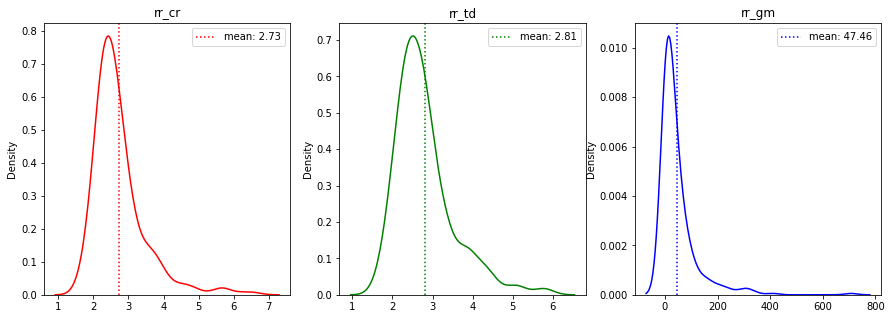

In [109]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
fig, axes  = plt.subplots(1,3,figsize=(15,5))

import seaborn as sns
for idx,_ in enumerate(imbalance_scores_df.design.unique()):
    sns.kdeplot(np.concatenate(imbalance_scores_df[imbalance_scores_df.design== _][['grp1','grp2','grp3']].values), ax=axes[idx], color=['r','g','b'][idx])
    mean = round(np.mean(imbalance_scores_df[imbalance_scores_df.design== _][['grp1','grp2','grp3']].values),2)
    axes[idx].axvline(np.mean(imbalance_scores_df[imbalance_scores_df.design== _][['grp1','grp2','grp3']].values), linestyle='dotted', color=['r','g','b'][idx], label='mean: '+str(mean))
    axes[idx].set_title(_)
    axes[idx].legend()
    

**Power Analysis: (To Do)**

In [ ]:
def train_test_indices_f(L, test_length, train_length = None):
    if not train_length:
        train_length = L-test_length
        
    assert train_length + test_length <= L, "Train + Test Length must be less or equal to available data points "
    train_test_indices = []

    indices = range(L)
    for i in range(L):
        start = i
        end = start+train_length

        train = np.take(indices, [range(i,end)], mode='wrape')
        test = np.take(indices, [range(end,end+test_length)], mode='wrape')
        train_test_indices.append(list(train) + list(test))
    
    return train_test_indices


def fake_effect(mod_pds, effect = 0):
    mod_fe_pds = copy.deepcopy(mod_pds)
    mask = ~(mod_pds.times>=mod_pds.times[mod_pds.treated_start_idxs[0]])&(mod_pds.times<=mod_pds.times[mod_pds.treated_end_idxs[0]-1])
    mod_fe_pds.wide_data.loc[mod_fe_pds.treated_units] = mod_fe_pds.wide_data.loc[mod_fe_pds.treated_units].where(mask.reshape(mod_fe_pds.wide_data.loc[mod_fe_pds.treated_units].shape)
                                                             , mod_fe_pds.wide_data.loc[mod_fe_pds.treated_units]+effect
                                                             )
    return mod_fe_pds

In [ ]:
panel_data = long_df_to_paneldataset(data, "date", "geo", "response2")

control_units = pd.DataFrame(panel_data.wide_data.loc[test2_results['ci_scores'].iloc[0,8]]).T
treated_units = pd.DataFrame(panel_data.wide_data.loc[test2_results['ci_scores'].iloc[0,7]].mean(axis=0), columns=['treated'])
wide_agg = pd.concat([treated_units, control_units], axis=1)

end = panel_data.times[-1]
L = len(panel_data.times)
test_length = 28

panel_data = PanelDataset(wide_agg.T, treated_units = ['treated'])

tt = train_test_indices_f(L, test_length)

output = []
iteration = 0 

mean_value = panel_data.wide_data.loc[panel_data.treated_units].mean().mean()
fake_effects = np.linspace(-.5*mean_value, .5*mean_value, 50)

In [ ]:
for k in tt:
    train = k[0]
    test = k[1]
    mod_df = pd.concat([panel_data.wide_data.T.iloc[train], panel_data.wide_data.T.iloc[test]]).reset_index(drop=True)
    mod_pds = PanelDataset(mod_df.T, [TimePeriod(start=L-test_length)], ['treated'])
    
    for effect in fake_effects:

        mod_fe_pds = fake_effect(mod_pds, effect = effect)
        model = SyntheticControl(inference='Kfold' )

        model.run_analysis(mod_fe_pds )
        
        cum_effect = (model.results['y'] - model.results['y_hat'])[-test_length:].sum()
        mean_effect = (model.results['y'] - model.results['y_hat'])[-test_length:].mean()
        
        cum_effect_low = (model.results['y'] - model.results['y_lower'])[-test_length:].sum()
        cum_effect_high = (model.results['y'] - model.results['y_upper'])[-test_length:].sum()

        mean_effect_low = (model.results['y'] - model.results['y_lower'])[-test_length:].mean()
        mean_effect_high = (model.results['y'] - model.results['y_upper'])[-test_length:].mean()
        
        mean_ss = mean_effect_low <= 0 <= mean_effect_high
        cum_ss = cum_effect_low <= 0 <= cum_effect_high
        
        output.append([iteration, effect, cum_effect, mean_effect_low, mean_effect, mean_effect_high, mean_ss, cum_ss])

    print(iteration, len(tt))
    iteration += 1